Manual Monte Carlo European call price (NumPy paths): 10.6185 ± 0.2891 (95% CI)


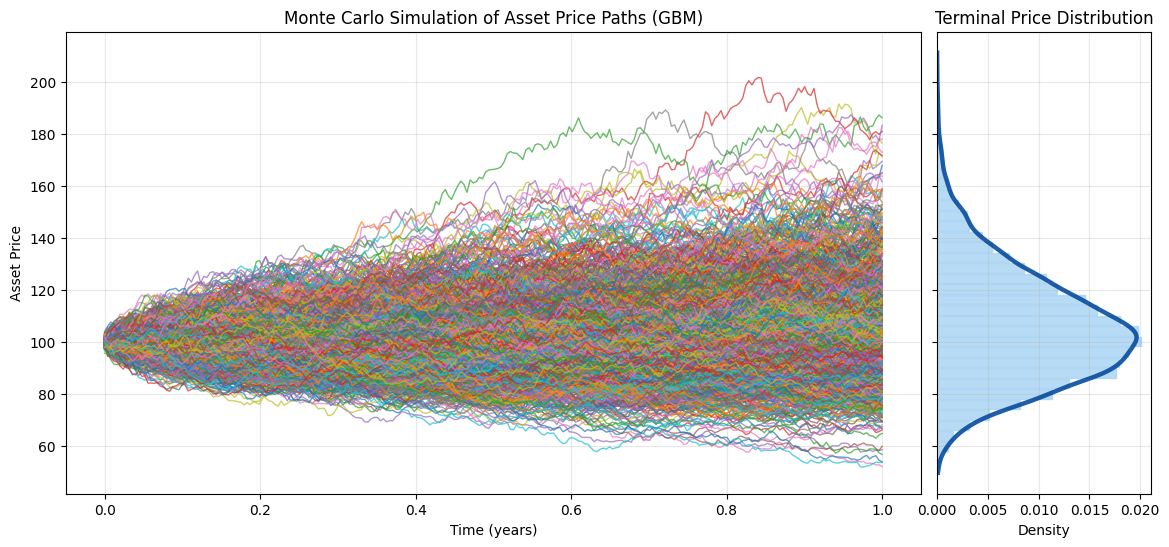

QuantLib Black–Scholes European call price (analytic): 10.4506
  Delta: 0.636831
  Gamma: 0.018762
  Vega : 37.524035
QuantLib Binomial (CRR, N=252) call price: 10.4424
QuantLib Monte Carlo European call price (timeSteps=252, paths=10000): 10.4720


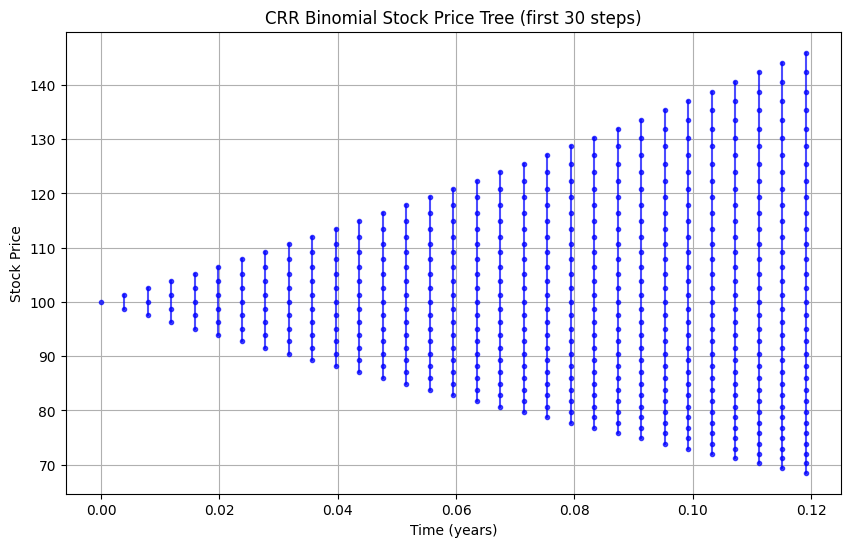

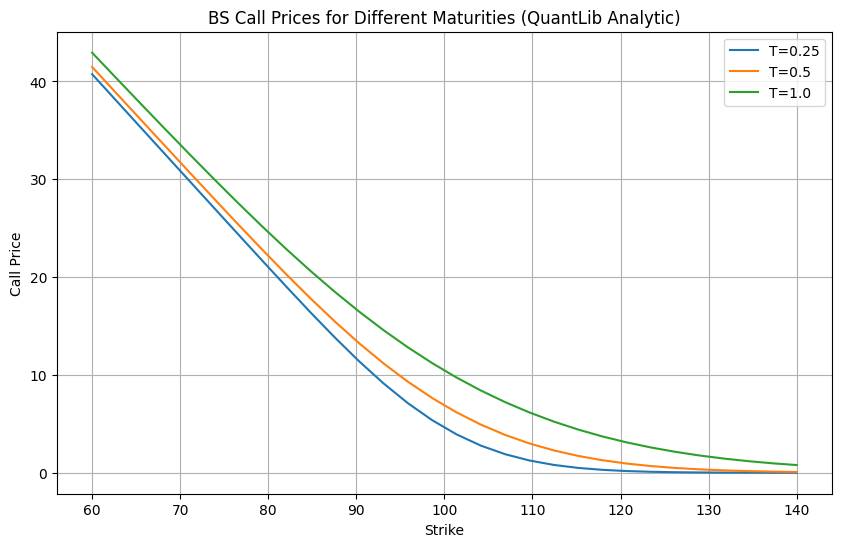

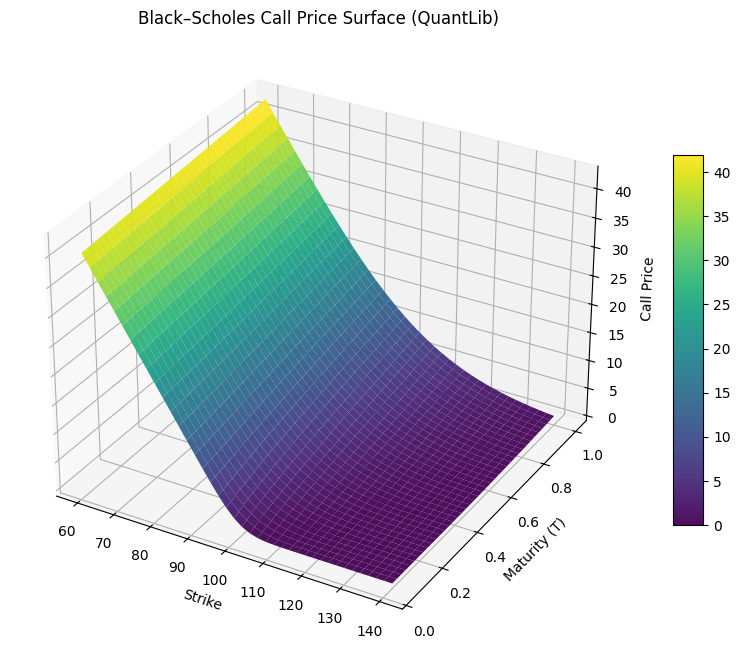

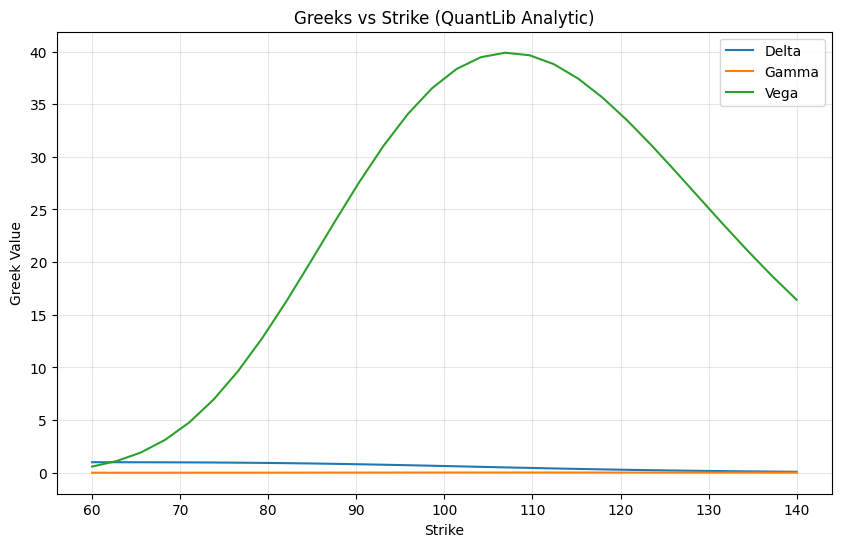

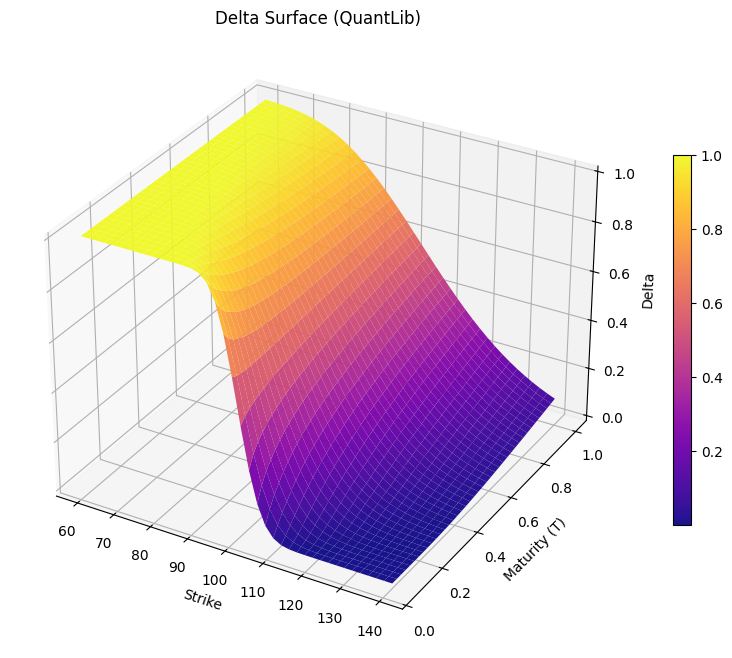

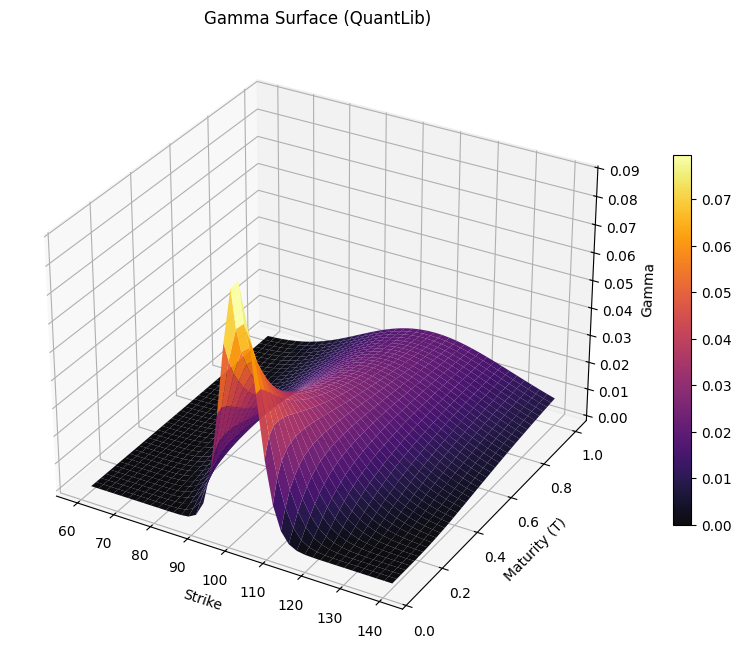

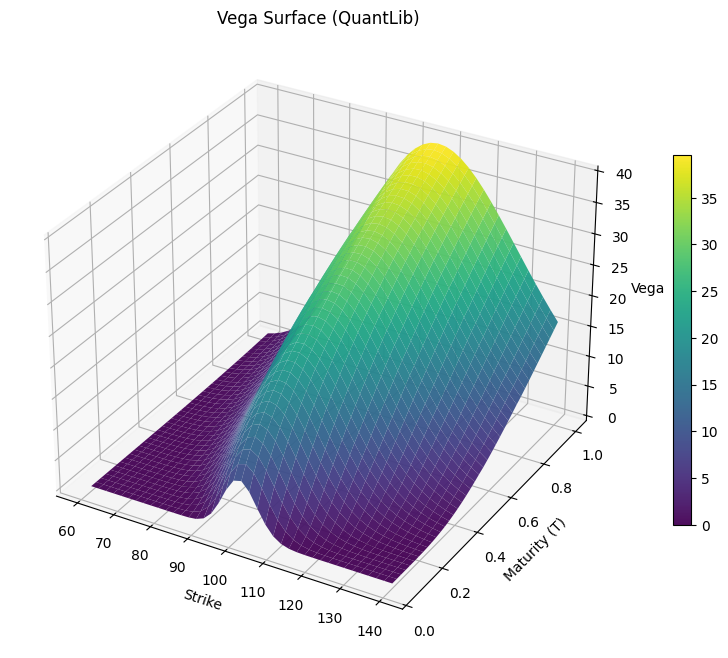

In [1]:
"""
Full option pricing notebook using QuantLib + NumPy + Matplotlib

Content:
1. Setup & parameters
2. QuantLib market objects (spot, curve, vol, process)
3. Monte Carlo GBM simulation (NumPy) + terminal distribution viz
4. European call pricing:
   - Monte Carlo price (QuantLib MCEngine)
   - Black–Scholes analytic price (QuantLib AnalyticEuropeanEngine)
   - Binomial CRR price (QuantLib BinomialVanillaEngine)
5. Binomial tree slice visualization (manual tree for plotting)
6. BS call prices vs strike & maturities (QuantLib)
7. BS call price surface vs strike & maturity (QuantLib)
8. Greeks (Delta, Gamma, Vega) vs strike (QuantLib)
9. Greeks surfaces (Delta, Gamma, Vega) vs strike & maturity (QuantLib)
"""

import numpy as np
import matplotlib.pyplot as plt

from math import log, sqrt, exp
from scipy.stats import norm
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.gridspec as gridspec

import QuantLib as ql


# -----------------------------------------------------------------------------
# 1. Parameters (arbitrary, similar to your original)
# -----------------------------------------------------------------------------
spot_initial          = 100.0      # initial stock price
strike_price          = 100.0      # strike price
rate_risk_free        = 0.05       # risk-free rate
volatility            = 0.20       # volatility
maturity_time         = 1.0        # time to maturity in years
step_number_time      = 252        # number of time steps
path_number_monte_carlo = 10000    # number of Monte Carlo paths

dividend_yield        = 0.0        # flat dividend yield

time_step_size        = maturity_time / step_number_time


# -----------------------------------------------------------------------------
# 2. QuantLib market setup
# -----------------------------------------------------------------------------
"""
We build the standard Black–Scholes–Merton setup in QuantLib:
- evaluation date
- spot quote
- flat risk-free curve
- flat dividend curve
- flat vol surface
- BS-Merton process
"""

calendar_quantlib   = ql.NullCalendar()
day_counter_quantlib = ql.Actual365Fixed()

evaluation_date     = ql.Date(1, 1, 2025)
ql.Settings.instance().evaluationDate = evaluation_date

spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot_initial))

rate_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(evaluation_date, rate_risk_free, day_counter_quantlib)
)

dividend_curve = ql.YieldTermStructureHandle(
    ql.FlatForward(evaluation_date, dividend_yield, day_counter_quantlib)
)

vol_surface = ql.BlackVolTermStructureHandle(
    ql.BlackConstantVol(evaluation_date, calendar_quantlib, volatility, day_counter_quantlib)
)

process_black_scholes = ql.BlackScholesMertonProcess(
    spot_handle, dividend_curve, rate_curve, vol_surface
)


def pricing_build_european_option(
    strike_value,
    maturity_years,
    option_type=ql.Option.Call
):
    """
    Helper: build a QuantLib European VanillaOption for given strike & maturity.
    """
    payoff_object = ql.PlainVanillaPayoff(option_type, strike_value)
    maturity_date = evaluation_date + int(365 * maturity_years)
    exercise_object = ql.EuropeanExercise(maturity_date)
    option_object = ql.VanillaOption(payoff_object, exercise_object)
    return option_object


# -----------------------------------------------------------------------------
# 3. Monte Carlo GBM simulation under risk-neutral measure (NumPy) + viz
#    (visuals done manually; pricing will also be done using QuantLib MC)
# -----------------------------------------------------------------------------
random_normals = np.random.normal(size=(path_number_monte_carlo, step_number_time))
increments_array = (
    (rate_risk_free - 0.5 * volatility**2) * time_step_size
    + volatility * np.sqrt(time_step_size) * random_normals
)

log_spot_paths = np.log(spot_initial) + np.cumsum(increments_array, axis=1)
spot_path_matrix = np.exp(log_spot_paths)

spot_terminal_values = spot_path_matrix[:, -1]

payoff_terminal_array = np.maximum(spot_terminal_values - strike_price, 0.0)
discount_factor_value = np.exp(-rate_risk_free * maturity_time)

monte_carlo_price_manual = discount_factor_value * np.mean(payoff_terminal_array)
standard_error_manual = (
    discount_factor_value
    * np.std(payoff_terminal_array)
    / np.sqrt(path_number_monte_carlo)
)

print(
    f"Manual Monte Carlo European call price (NumPy paths): "
    f"{monte_carlo_price_manual:.4f} ± {1.96 * standard_error_manual:.4f} (95% CI)"
)

# Plot a subset of paths + terminal distribution (as in your original)
path_number_plot = 1000
time_grid_values = np.linspace(0.0, maturity_time, step_number_time)

plt.figure(figsize=(14, 6))
grid_spec = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.03)

# left: GBM simulation
axis_paths = plt.subplot(grid_spec[0])
for path_index in range(path_number_plot):
    axis_paths.plot(time_grid_values, spot_path_matrix[path_index], linewidth=1, alpha=0.7)

axis_paths.set_title("Monte Carlo Simulation of Asset Price Paths (GBM)")
axis_paths.set_xlabel("Time (years)")
axis_paths.set_ylabel("Asset Price")
axis_paths.grid(True, alpha=0.3)

# right: histogram + KDE of terminal prices
axis_histogram = plt.subplot(grid_spec[1], sharey=axis_paths)

hist_counts, hist_edges = np.histogram(spot_terminal_values, bins=40, density=True)
hist_centers = (hist_edges[:-1] + hist_edges[1:]) / 2.0
hist_width = hist_edges[1] - hist_edges[0]

axis_histogram.barh(
    hist_centers,
    hist_counts,
    height=hist_width * 0.9,
    color="#A7D3F3",
    alpha=0.8,
    edgecolor="#A7D3F3",
)

kde_object = gaussian_kde(spot_terminal_values)
density_y_values = np.linspace(min(spot_terminal_values), max(spot_terminal_values), 200)
density_x_values = kde_object(density_y_values)

axis_histogram.plot(
    density_x_values,
    density_y_values,
    color="#084C9E",
    linewidth=3.2,
    alpha=0.9,
)

axis_histogram.set_title("Terminal Price Distribution")
axis_histogram.set_xlabel("Density")
axis_histogram.set_ylabel("")
axis_histogram.tick_params(axis="y", labelleft=False)
axis_histogram.grid(True, alpha=0.3)
axis_histogram.set_ylim(axis_paths.get_ylim())

plt.gcf().set_constrained_layout_pads(w_pad=0.02, h_pad=0.02)
plt.show()


# -----------------------------------------------------------------------------
# 4. European call pricing via QuantLib
#    (a) Analytic BS engine
#    (b) Binomial CRR engine
#    (c) Monte Carlo engine
# -----------------------------------------------------------------------------
option_european = pricing_build_european_option(strike_price, maturity_time)

# (a) Analytic Black–Scholes engine
analytic_engine = ql.AnalyticEuropeanEngine(process_black_scholes)
option_european.setPricingEngine(analytic_engine)
bs_price_quantlib = option_european.NPV()
delta_quantlib = option_european.delta()
gamma_quantlib = option_european.gamma()
vega_quantlib = option_european.vega()

print(f"QuantLib Black–Scholes European call price (analytic): {bs_price_quantlib:.4f}")
print(f"  Delta: {delta_quantlib:.6f}")
print(f"  Gamma: {gamma_quantlib:.6f}")
print(f"  Vega : {vega_quantlib:.6f}")

# (b) Binomial CRR engine
step_number_binomial = step_number_time

binomial_engine = ql.BinomialVanillaEngine(
    process_black_scholes,
    "CRR",
    step_number_binomial
)
option_european.setPricingEngine(binomial_engine)
binomial_price_quantlib = option_european.NPV()
print(f"QuantLib Binomial (CRR, N={step_number_binomial}) call price: {binomial_price_quantlib:.4f}")

# (c) Monte Carlo engine
monte_carlo_engine = ql.MCEuropeanEngine(
    process_black_scholes,
    "pseudorandom",
    timeSteps=step_number_time,
    requiredSamples=path_number_monte_carlo
)
option_european.setPricingEngine(monte_carlo_engine)
monte_carlo_price_quantlib = option_european.NPV()
print(
    "QuantLib Monte Carlo European call price "
    f"(timeSteps={step_number_time}, paths={path_number_monte_carlo}): "
    f"{monte_carlo_price_quantlib:.4f}"
)


# -----------------------------------------------------------------------------
# 5. Binomial tree slice visualization (manual tree construction, as before)
# -----------------------------------------------------------------------------
"""
QuantLib does not directly expose the binomial tree nodes from Python,
so we build the CRR tree manually for visualization, while still using
QuantLib for the actual option price printed above.
"""

step_number_tree = step_number_binomial
time_step_binomial = maturity_time / step_number_tree

up_factor = np.exp(volatility * np.sqrt(time_step_binomial))
down_factor = 1.0 / up_factor
probability_risk_neutral = (
    (np.exp(rate_risk_free * time_step_binomial) - down_factor)
    / (up_factor - down_factor)
)
discount_factor_binomial = np.exp(-rate_risk_free * time_step_binomial)

stock_tree_matrix = np.zeros((step_number_tree + 1, step_number_tree + 1))

for step_index in range(step_number_tree + 1):
    for up_index in range(step_index + 1):
        stock_tree_matrix[step_index, up_index] = (
            spot_initial * (up_factor ** up_index) * (down_factor ** (step_index - up_index))
        )

# plot first 30 steps
maximum_plot_steps = 30
steps_to_plot = min(step_number_tree, maximum_plot_steps)

plt.figure(figsize=(10, 6))
for step_index in range(steps_to_plot + 1):
    x_values_plot = np.full(step_index + 1, step_index * time_step_binomial)
    y_values_plot = stock_tree_matrix[step_index, :step_index + 1]
    plt.plot(x_values_plot, y_values_plot, "bo-", markersize=3, alpha=0.7)

plt.title("CRR Binomial Stock Price Tree (first 30 steps)")
plt.xlabel("Time (years)")
plt.ylabel("Stock Price")
plt.grid(True)
plt.show()


# -----------------------------------------------------------------------------
# 6. BS call prices vs strike & maturities using QuantLib
# -----------------------------------------------------------------------------
strike_values = np.linspace(60.0, 140.0, 30)
maturity_values = [0.25, 0.5, 1.0]
volatility_values = [0.10, 0.20, 0.30]  # not used directly in QuantLib grid, but kept for info

plt.figure(figsize=(10, 6))

for maturity_value in maturity_values:
    call_price_list = []
    for strike_value in strike_values:
        option_temp = pricing_build_european_option(strike_value, maturity_value)
        option_temp.setPricingEngine(analytic_engine)
        call_price_list.append(option_temp.NPV())
    plt.plot(strike_values, call_price_list, label=f"T={maturity_value}")

plt.title("BS Call Prices for Different Maturities (QuantLib Analytic)")
plt.xlabel("Strike")
plt.ylabel("Call Price")
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------------------------------------------------------
# 7. 3D price surface vs strike & maturity using QuantLib
# -----------------------------------------------------------------------------
strike_grid = np.linspace(60.0, 140.0, 40)
maturity_grid = np.linspace(0.05, 1.0, 40)

strike_mesh, maturity_mesh = np.meshgrid(strike_grid, maturity_grid)

price_mesh = np.zeros_like(strike_mesh)

for i in range(maturity_mesh.shape[0]):
    for j in range(maturity_mesh.shape[1]):
        strike_value = strike_mesh[i, j]
        maturity_value = maturity_mesh[i, j]
        option_temp = pricing_build_european_option(strike_value, maturity_value)
        option_temp.setPricingEngine(analytic_engine)
        price_mesh[i, j] = option_temp.NPV()

fig = plt.figure(figsize=(12, 8))
axis_surface = fig.add_subplot(111, projection="3d")

surface_plot = axis_surface.plot_surface(
    strike_mesh,
    maturity_mesh,
    price_mesh,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)

fig.colorbar(surface_plot, shrink=0.6, aspect=12)

axis_surface.set_title("Black–Scholes Call Price Surface (QuantLib)")
axis_surface.set_xlabel("Strike")
axis_surface.set_ylabel("Maturity (T)")
axis_surface.set_zlabel("Call Price")

plt.show()


# -----------------------------------------------------------------------------
# 8. Greeks vs strike using QuantLib (Delta, Gamma, Vega)
# -----------------------------------------------------------------------------
delta_values = []
gamma_values = []
vega_values = []

for strike_value in strike_values:
    option_temp = pricing_build_european_option(strike_value, maturity_time)
    option_temp.setPricingEngine(analytic_engine)
    delta_values.append(option_temp.delta())
    gamma_values.append(option_temp.gamma())
    vega_values.append(option_temp.vega())

plt.figure(figsize=(10, 6))
plt.plot(strike_values, delta_values, label="Delta")
plt.plot(strike_values, gamma_values, label="Gamma")
plt.plot(strike_values, vega_values, label="Vega")
plt.title("Greeks vs Strike (QuantLib Analytic)")
plt.xlabel("Strike")
plt.ylabel("Greek Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


# -----------------------------------------------------------------------------
# 9. Greeks surfaces vs strike & maturity using QuantLib
# -----------------------------------------------------------------------------
strike_mesh_greeks, maturity_mesh_greeks = np.meshgrid(strike_grid, maturity_grid)

delta_mesh = np.zeros_like(strike_mesh_greeks)
gamma_mesh = np.zeros_like(strike_mesh_greeks)
vega_mesh = np.zeros_like(strike_mesh_greeks)

for i in range(maturity_mesh_greeks.shape[0]):
    for j in range(maturity_mesh_greeks.shape[1]):
        strike_value = strike_mesh_greeks[i, j]
        maturity_value = maturity_mesh_greeks[i, j]
        option_temp = pricing_build_european_option(strike_value, maturity_value)
        option_temp.setPricingEngine(analytic_engine)
        delta_mesh[i, j] = option_temp.delta()
        gamma_mesh[i, j] = option_temp.gamma()
        vega_mesh[i, j] = option_temp.vega()

# Delta surface
fig = plt.figure(figsize=(12, 8))
axis_delta = fig.add_subplot(111, projection="3d")
surface_delta = axis_delta.plot_surface(
    strike_mesh_greeks, maturity_mesh_greeks, delta_mesh, cmap="plasma", alpha=0.95
)
fig.colorbar(surface_delta, shrink=0.6)
axis_delta.set_title("Delta Surface (QuantLib)")
axis_delta.set_xlabel("Strike")
axis_delta.set_ylabel("Maturity (T)")
axis_delta.set_zlabel("Delta")
plt.show()

# Gamma surface
fig = plt.figure(figsize=(12, 8))
axis_gamma = fig.add_subplot(111, projection="3d")
surface_gamma = axis_gamma.plot_surface(
    strike_mesh_greeks, maturity_mesh_greeks, gamma_mesh, cmap="inferno", alpha=0.95
)
fig.colorbar(surface_gamma, shrink=0.6)
axis_gamma.set_title("Gamma Surface (QuantLib)")
axis_gamma.set_xlabel("Strike")
axis_gamma.set_ylabel("Maturity (T)")
axis_gamma.set_zlabel("Gamma")
plt.show()

# Vega surface
fig = plt.figure(figsize=(12, 8))
axis_vega = fig.add_subplot(111, projection="3d")
surface_vega = axis_vega.plot_surface(
    strike_mesh_greeks, maturity_mesh_greeks, vega_mesh, cmap="viridis", alpha=0.95
)
fig.colorbar(surface_vega, shrink=0.6)
axis_vega.set_title("Vega Surface (QuantLib)")
axis_vega.set_xlabel("Strike")
axis_vega.set_ylabel("Maturity (T)")
axis_vega.set_zlabel("Vega")
plt.show()


In [2]:
"""
WORKING Heston implementations for QuantLib-Python
- Analytic
- Monte Carlo
"""

# Heston parameters
heston_v0      = volatility**2
heston_kappa   = 1.5
heston_theta   = volatility**2
heston_sigma   = 0.3
heston_rho     = -0.6

process_heston = ql.HestonProcess(
    rate_curve,
    dividend_curve,
    spot_handle,
    heston_v0,
    heston_kappa,
    heston_theta,
    heston_sigma,
    heston_rho
)

model_heston = ql.HestonModel(process_heston)

# Build option
option_heston = pricing_build_european_option(strike_price, maturity_time)


# --- Analytic Heston Engine
engine_heston_analytic = ql.AnalyticHestonEngine(model_heston)
option_heston.setPricingEngine(engine_heston_analytic)

heston_price_analytic = option_heston.NPV()
print(f"Heston analytic price: {heston_price_analytic:.6f}")


# --- Heston Monte Carlo (Python bindings fully support this)
engine_heston_mc = ql.MCEuropeanHestonEngine(
    process_heston,
    "pseudorandom",
    timeSteps=step_number_time,
    requiredSamples=20000
)

option_heston.setPricingEngine(engine_heston_mc)
heston_price_mc = option_heston.NPV()
print(f"Heston Monte Carlo price: {heston_price_mc:.6f}")

Heston analytic price: 10.347298
Heston Monte Carlo price: 10.346216


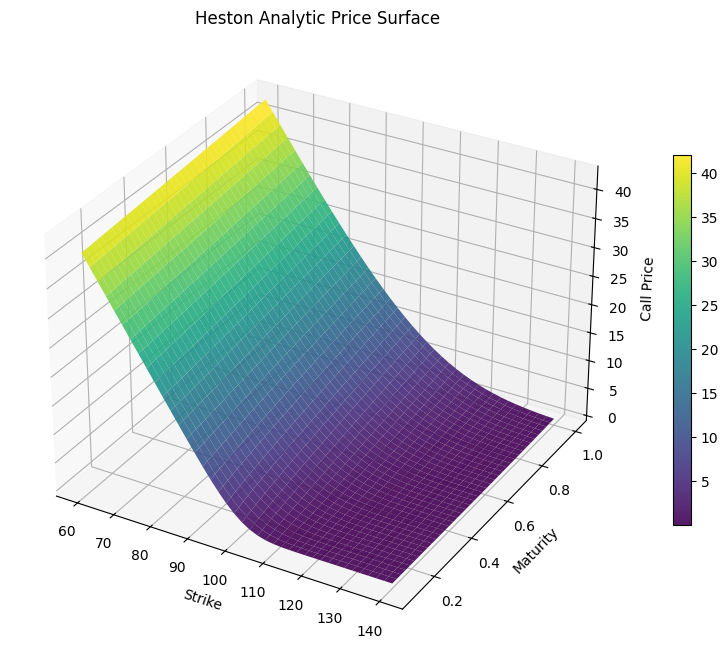

In [3]:
"""
Heston analytic price surface vs strike & maturity.
"""

strike_range_surface = np.linspace(60, 140, 40)
maturity_range_surface = np.linspace(0.1, 1.0, 40)

strike_mesh_heston, maturity_mesh_heston = np.meshgrid(
    strike_range_surface, maturity_range_surface
)

price_mesh_heston = np.zeros_like(strike_mesh_heston)

for i in range(price_mesh_heston.shape[0]):
    for j in range(price_mesh_heston.shape[1]):
        strike_val = strike_mesh_heston[i, j]
        tau_val    = maturity_mesh_heston[i, j]

        opt_tmp = pricing_build_european_option(strike_val, tau_val)
        opt_tmp.setPricingEngine(engine_heston_analytic)
        price_mesh_heston[i, j] = opt_tmp.NPV()

# Plot surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    strike_mesh_heston,
    maturity_mesh_heston,
    price_mesh_heston,
    cmap='viridis',
    linewidth=0,
    alpha=0.9
)

ax.set_title("Heston Analytic Price Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity")
ax.set_zlabel("Call Price")
fig.colorbar(surf, shrink=0.6)
plt.show()

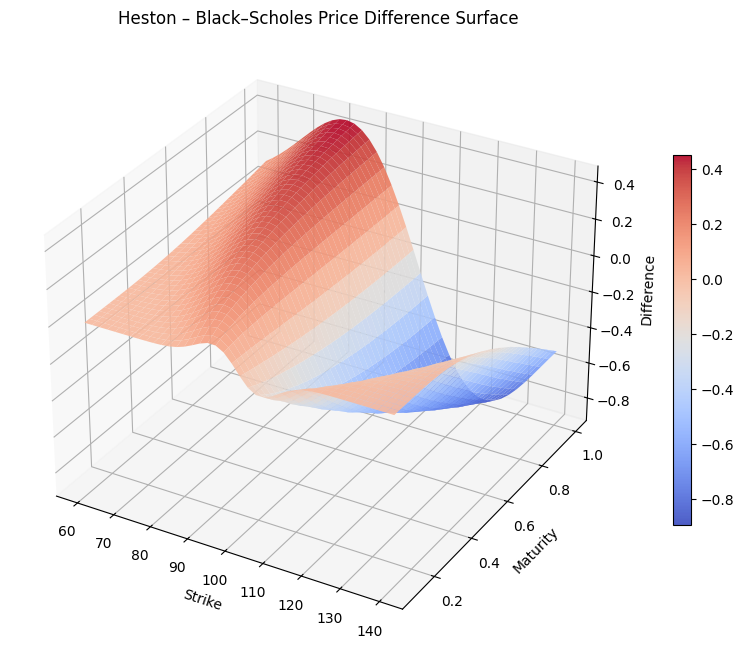

In [4]:
"""
Heston – Black–Scholes price difference surface.
"""

price_diff_mesh = np.zeros_like(price_mesh_heston)

for i in range(price_mesh_heston.shape[0]):
    for j in range(price_mesh_heston.shape[1]):
        strike_val = strike_mesh_heston[i, j]
        tau_val    = maturity_mesh_heston[i, j]

        # BS price
        opt_bs = pricing_build_european_option(strike_val, tau_val)
        opt_bs.setPricingEngine(analytic_engine)  # your BS analytic engine
        bs_price = opt_bs.NPV()

        price_diff_mesh[i, j] = price_mesh_heston[i, j] - bs_price

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(strike_mesh_heston, maturity_mesh_heston, price_diff_mesh,
                       cmap='coolwarm', linewidth=0, alpha=0.9)
ax.set_title("Heston – Black–Scholes Price Difference Surface")
ax.set_xlabel("Strike")
ax.set_ylabel("Maturity")
ax.set_zlabel("Difference")
fig.colorbar(surf, shrink=0.6)
plt.show()


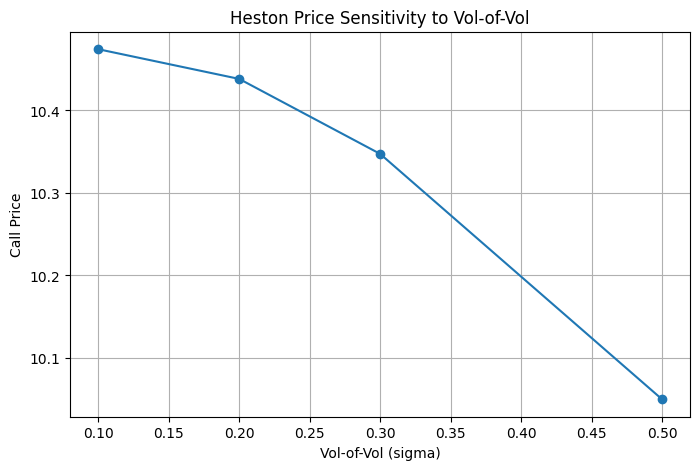

In [5]:
"""
Heston sensitivity to vol-of-vol parameter.
"""

sigma_values = [0.1, 0.2, 0.3, 0.5]
price_vs_sigma = []

for sig in sigma_values:
    model_tmp = ql.HestonModel(
        ql.HestonProcess(rate_curve, dividend_curve, spot_handle,
                         heston_v0, heston_kappa, heston_theta, sig, heston_rho)
    )
    opt_tmp = pricing_build_european_option(strike_price, maturity_time)
    opt_tmp.setPricingEngine(ql.AnalyticHestonEngine(model_tmp))
    price_vs_sigma.append(opt_tmp.NPV())

plt.figure(figsize=(8, 5))
plt.plot(sigma_values, price_vs_sigma, marker='o')
plt.title("Heston Price Sensitivity to Vol-of-Vol")
plt.xlabel("Vol-of-Vol (sigma)")
plt.ylabel("Call Price")
plt.grid(True)
plt.show()
